<a id="title"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:20px 20px;">**Centerline Extraction: Hybrid Approach**</p>

## Method Overview: Automated Hybrid Centerline Extraction

This notebook implements a **fully automated, hybrid approach** for coronary artery centerline extraction. It combines two complementary techniques:

1. **Voxel-based topological thinning** (adapted from Maren Clapers' work) — used as an automated "scout" to separate the RCA and LCA arteries and discover seed points (ostium and branch tips) without any manual interaction.
2. **VMTK Voronoi-based centerline extraction** — the mathematically precise algorithm that computes smooth centerlines with **maximum inscribed sphere radii**, the key quantity for downstream stenosis quantification.

### Why a Hybrid?

| Approach | Strength | Weakness |
|----------|----------|----------|
| **Skeletonization (Maren)** | Fully automatic, finds all endpoints | Produces only voxel-resolution coordinates, no inscribed radius |
| **VMTK Centerlines (Oscar)** | Mathematically smooth, provides inscribed radii | Requires manual seed point selection |

By using skeletonization to **automate the seed selection** and then feeding those seeds into VMTK, we get the best of both worlds: a **fully automated pipeline** that outputs clinically useful centerlines with radius data.

### Workflow

```
 .nrrd Binary Mask
        │
        ▼
 ┌──────────────────────────┐
 │  vmtkImageReader          │──► VTK Image ──► NumPy Array
 └────────────┬─────────────┘
              │
              ▼
 ┌──────────────────────────┐
 │  scipy.ndimage.label      │──► Connected Components
 │  center_of_mass (X-axis)  │──► RCA / LCA identification
 └──────┬──────────┬────────┘
        │          │
       RCA        LCA          ◄── same pipeline runs for each
        │          │
        ▼          ▼
 ┌──────────────────────────┐
 │  SCOUT (Phase 2)          │
 │   skeletonize_3d          │──► 1-voxel skeleton
 │   find endpoints          │──► voxels with 1 neighbour
 │   distance_transform_edt  │──► endpoint deepest inside = Ostium
 │   voxel → physical mm     │──► Source + Targets
 └────────────┬─────────────┘
              │
              ▼
 ┌──────────────────────────┐
 │  VMTK (Phase 3)           │
 │   vmtkMarchingCubes       │──► smooth surface mesh
 │   vmtkSurfaceSmoothing    │
 │   vmtkCenterlines         │──► points + inscribed radii
 └────────────┬─────────────┘
              │
              ▼
 ┌──────────────────────────┐
 │  Pandas DataFrame         │
 │   Sample_ID, Artery_Type  │
 │   Px, Py, Pz, Radius     │
 └──────────────────────────┘
```

<a id="step1"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">1. Imports & Configuration</p>

In [1]:
import sys
import types
from pathlib import Path

import numpy as np
import pandas as pd
import pyvista as pv
import scipy.ndimage as ndi
from skimage.morphology import skeletonize
from vtkmodules.util.numpy_support import vtk_to_numpy, numpy_to_vtk
from vtkmodules.vtkCommonDataModel import vtkImageData
from vmtk import vmtkscripts

# The vmtk conda-forge build strips vtkRenderingMatplotlib.
# Inject a dummy so PyVista skips it gracefully.
sys.modules.setdefault(
    "vtkmodules.vtkRenderingMatplotlib",
    types.ModuleType("vtkmodules.vtkRenderingMatplotlib"),
)

<module 'vtkmodules.vtkRenderingMatplotlib'>

In [2]:
SAMPLE_ID = 1


def _find_asoca_normal_data_root() -> Path:
    """Locate repo `data/ASOCA Normal` regardless of Jupyter cwd (repo root, notebooks/, or block1_extraction/)."""
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        cand = base / "data" / "ASOCA Normal"
        if cand.is_dir():
            return cand
    return (here / "data" / "ASOCA Normal").resolve()


DATA_ROOT = _find_asoca_normal_data_root()
NRRD_PATH = (DATA_ROOT / "Annotations" / f"Normal_{SAMPLE_ID}.nrrd").resolve()

for _backend in ("trame", "static"):
    try:
        pv.set_jupyter_backend(_backend)
        break
    except Exception:
        continue

print(f"Sample    : Normal_{SAMPLE_ID}")
print(f"DATA_ROOT : {DATA_ROOT}")
print(f"NRRD path : {NRRD_PATH}")
print(f"Exists    : {NRRD_PATH.exists()}")
if not NRRD_PATH.exists():
    ann = DATA_ROOT / "Annotations"
    print(
        "\nIf Exists is False: either place masks under "
        f"{ann} (e.g. Normal_1.nrrd) or fix DATA_ROOT; "
        "the old `../data/...` path depended on the notebook working directory."
    )

Sample    : Normal_1
DATA_ROOT : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\data\ASOCA Normal
NRRD path : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\data\ASOCA Normal\Annotations\Normal_1.nrrd
Exists    : True


<a id="step2"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">2. Phase 1: Mask Loading & RCA/LCA Separation</p>

The ASOCA binary mask contains the **entire coronary artery tree** — both the Right Coronary Artery (RCA) and the Left Coronary Artery (LCA) — in a single label. Before we can process each artery independently, we need to:

1. **Load the mask** with `vmtkImageReader` to retain VTK spatial metadata (spacing, origin).
2. **Convert** the VTK image to a NumPy array using `vtk_to_numpy` for image-processing operations.
3. **Label connected components** using `scipy.ndimage.label` — the RCA and LCA are physically disconnected in the segmentation, so they appear as separate 3D blobs.
4. **Identify** which component is the RCA and which is the LCA using their **center of mass**: in standard CT patient coordinates, the RCA sits to the patient's right (lower physical X-coordinate) and the LCA to the patient's left (higher physical X-coordinate).

This separation logic is adapted from Maren Clapers' `rca_lca_separation.ipynb`.

In [3]:
# ── 2a. Load the mask with VMTK (retains spacing & origin) ──────────────
reader = vmtkscripts.vmtkImageReader()
reader.InputFileName = str(NRRD_PATH)
reader.Execute()

vtk_image = reader.Image
spacing = np.array(vtk_image.GetSpacing())   # (sx, sy, sz) mm
origin  = np.array(vtk_image.GetOrigin())    # (ox, oy, oz) mm
dims    = vtk_image.GetDimensions()          # (nx, ny, nz)

print(f"Dimensions : {dims}")
print(f"Spacing    : {spacing}")
print(f"Origin     : {origin}")

# ── 2b. Convert VTK image → NumPy array in (Z, Y, X) order ─────────────
vtk_scalars = vtk_image.GetPointData().GetScalars()
mask_flat = vtk_to_numpy(vtk_scalars)
mask = mask_flat.reshape(dims[2], dims[1], dims[0]).astype(np.uint8)

print(f"\nNumPy mask shape (Z, Y, X) : {mask.shape}")
print(f"Labeled voxels             : {np.count_nonzero(mask):,}")

# ── 2c. Separate connected components ───────────────────────────────────
labeled, num_components = ndi.label(mask)
print(f"Connected components found : {num_components}")

# Keep only the two largest (ignore small noise fragments)
component_sizes = ndi.sum(mask, labeled, range(1, num_components + 1))
sorted_labels = np.argsort(component_sizes)[::-1] + 1   # largest first, 1-indexed
label_a, label_b = sorted_labels[0], sorted_labels[1]

# ── 2d. Identify RCA vs LCA by center-of-mass physical X ───────────────
com_a = ndi.center_of_mass(mask, labeled, label_a)  # (z, y, x) voxel indices
com_b = ndi.center_of_mass(mask, labeled, label_b)

phys_x_a = origin[0] + com_a[2] * spacing[0]
phys_x_b = origin[0] + com_b[2] * spacing[0]

# RCA sits at lower physical X (patient's right)
if phys_x_a < phys_x_b:
    rca_label, lca_label = label_a, label_b
else:
    rca_label, lca_label = label_b, label_a

artery_arrays = {
    "RCA": (labeled == rca_label).astype(np.uint8),
    "LCA": (labeled == lca_label).astype(np.uint8),
}

for name, arr in artery_arrays.items():
    com = ndi.center_of_mass(arr)
    phys_x = origin[0] + com[2] * spacing[0]
    print(f"\n{name}: {np.count_nonzero(arr):,} voxels  |  "
          f"center-of-mass physical X = {phys_x:.1f} mm")

Spacing 0.416016 0.416016 0.625000
Origin 116.800003 120.000000 -196.875000
Dimensions 512 512 204
Dimensions : (512, 512, 204)
Spacing    : [0.416016 0.416016 0.625   ]
Origin     : [ 116.80000305  120.         -196.875     ]

NumPy mask shape (Z, Y, X) : (204, 512, 512)
Labeled voxels             : 36,104
Connected components found : 2

RCA: 19,946 voxels  |  center-of-mass physical X = 199.3 mm

LCA: 16,158 voxels  |  center-of-mass physical X = 249.9 mm


<a id="step3"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">3. Phase 2 & 3 — Automated Seed Extraction + VMTK Centerlines</p>

For each artery (RCA and LCA) we run the **core hybrid pipeline**:

**Phase 2 — The Scout (Automated Seed Points):**
1. **3D Skeletonization** (`skimage.skeletonize_3d`): Morphologically thins the binary mask down to a 1-voxel-thick skeleton, preserving topology. Adapted from Maren's `Skeletonization.ipynb`.
2. **Endpoint detection**: Skeleton voxels with exactly **1 neighbour** in a 3x3x3 cube are endpoints — they correspond to the ostium or distal branch tips.
3. **Ostium identification via Distance Transform**: `scipy.ndimage.distance_transform_edt` gives the Euclidean distance of each voxel to the nearest mask boundary. The endpoint with the **largest distance** sits deepest inside the thickest part of the vessel — the ostium. All other endpoints become targets.
4. **Coordinate conversion**: Voxel indices `(z, y, x)` are converted to physical mm using the VMTK Image origin and spacing (adapted from Maren's `voxels_to_points_df.ipynb`).

**Phase 3 — Mathematical Centerline (VMTK):**
1. Convert the single-artery NumPy mask back to a VTK image.
2. Run `vmtkMarchingCubes` + `vmtkSurfaceSmoothing` to build a smooth surface.
3. Snap the automated seed points to the nearest mesh vertex for robustness.
4. Feed them into `vmtkCenterlines` for exact Voronoi-based extraction.
5. Extract centerline coordinates and `MaximumInscribedSphereRadius` into a DataFrame.

In [4]:
# ═══════════════════════════════════════════════════════════════
#  Helper functions used by the main processing loop
# ═══════════════════════════════════════════════════════════════

def find_skeleton_endpoints(skeleton):
    """Find endpoints of a 3D skeleton (voxels with exactly 1 neighbour)."""
    kernel = np.ones((3, 3, 3), dtype=int)
    kernel[1, 1, 1] = 0                    # exclude the center voxel itself
    neighbor_count = ndi.convolve(
        skeleton.astype(int), kernel, mode="constant", cval=0
    )
    endpoint_mask = (skeleton > 0) & (neighbor_count == 1)
    return np.argwhere(endpoint_mask)       # (N, 3) array of [z, y, x] indices


def identify_ostium(
    endpoints_zyx,
    skeleton,
    binary_mask,
    edt_weight: float = 0.35,
    centroid_weight: float = 0.15,
    caliber_weight: float = 0.30,
    calib_steps: int = 3,
):
    """Robust ostium selection from skeleton endpoints.

    Score combines:
    - EDT depth at endpoint (higher is better)
    - skeleton geodesic centrality among endpoints (lower is better)
    - endpoint proximity to artery centroid (closer is better)
    - local caliber integral over next contiguous skeleton points

    Returns
    -------
    ostium_idx : int
    dists_edt : np.ndarray
    total_geo : np.ndarray
    caliber_sum : np.ndarray
    score : np.ndarray
    """
    # 1) EDT term
    dist_transform = ndi.distance_transform_edt(binary_mask)
    dists_edt = dist_transform[
        endpoints_zyx[:, 0], endpoints_zyx[:, 1], endpoints_zyx[:, 2]
    ].astype(float)

    # 2) Skeleton geodesic centrality term
    sk = np.asarray(skeleton > 0)
    sk_coords = np.argwhere(sk)
    node_of = {tuple(c): i for i, c in enumerate(sk_coords)}

    endpoint_nodes = []
    for p in endpoints_zyx:
        endpoint_nodes.append(node_of.get((int(p[0]), int(p[1]), int(p[2])), -1))
    endpoint_nodes = np.asarray(endpoint_nodes, dtype=int)

    # If graph mapping failed, fall back to EDT-only.
    if np.any(endpoint_nodes < 0) or len(sk_coords) == 0:
        total_geo = np.zeros_like(dists_edt)
        caliber_sum = dists_edt.copy()
        score = dists_edt.copy()
        return int(np.argmax(score)), dists_edt, total_geo, caliber_sum, score

    from heapq import heappop, heappush

    # 26-neighborhood in 3D with Euclidean move costs.
    neigh = []
    for dz in (-1, 0, 1):
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                if dz == 0 and dy == 0 and dx == 0:
                    continue
                w = float(np.sqrt(dx * dx + dy * dy + dz * dz))
                neigh.append((dz, dy, dx, w))

    # Build skeleton adjacency once (used for both Dijkstra and caliber walk).
    adjacency = [set() for _ in range(len(sk_coords))]
    for u, (z, y, x) in enumerate(sk_coords):
        for dz, dy, dx, _ in neigh:
            key = (int(z + dz), int(y + dy), int(x + dx))
            v = node_of.get(key)
            if v is None or v == u:
                continue
            adjacency[u].add(int(v))

    def dijkstra_from(src_idx: int) -> np.ndarray:
        n = len(sk_coords)
        dist = np.full(n, np.inf, dtype=float)
        dist[src_idx] = 0.0
        pq = [(0.0, int(src_idx))]
        while pq:
            d, u = heappop(pq)
            if d > dist[u]:
                continue
            z, y, x = sk_coords[u]
            for dz, dy, dx, w in neigh:
                key = (int(z + dz), int(y + dy), int(x + dx))
                v = node_of.get(key)
                if v is None:
                    continue
                nd = d + w
                if nd < dist[v]:
                    dist[v] = nd
                    heappush(pq, (nd, int(v)))
        return dist

    def local_caliber_integral(start_node: int, max_steps: int) -> float:
        """Follow contiguous branch points from endpoint and integrate caliber."""
        prev = -1
        cur = int(start_node)
        total = 0.0

        nsteps = int(max(1, max_steps))
        for _ in range(nsteps):
            z, y, x = sk_coords[cur]
            # Area proxy from EDT to emphasize larger vessel segment context.
            edt_here = float(dist_transform[int(z), int(y), int(x)])
            total += float(np.pi) * edt_here * edt_here

            next_nodes = [v for v in adjacency[cur] if v != prev]
            if len(next_nodes) == 0:
                break
            if len(next_nodes) > 1:
                # Stop at first bifurcation to keep local trunk evidence only.
                break

            nxt = int(next_nodes[0])
            prev, cur = cur, nxt

        return float(total)

    m = len(endpoint_nodes)
    pairwise = np.full((m, m), np.inf, dtype=float)
    for i in range(m):
        dist_all = dijkstra_from(int(endpoint_nodes[i]))
        pairwise[i, :] = dist_all[endpoint_nodes]

    # Centrality proxy: sum of geodesic distances to all other endpoints.
    total_geo = np.sum(pairwise, axis=1)

    # 3) Combined score
    def _z(v):
        v = np.asarray(v, dtype=float)
        return (v - np.mean(v)) / (np.std(v) + 1e-8)

    # Local caliber integral from each endpoint across contiguous skeleton points.
    caliber_sum = np.array(
        [local_caliber_integral(int(node), int(calib_steps)) for node in endpoint_nodes],
        dtype=float,
    )

    # Centroid prior: ostium tends to be close to the root-side centroid.
    mask_pts = np.argwhere(np.asarray(binary_mask) > 0)
    if len(mask_pts) > 0:
        centroid_zyx = mask_pts.mean(axis=0)
        d_centroid = np.linalg.norm(
            endpoints_zyx.astype(float) - centroid_zyx.astype(float), axis=1
        )
    else:
        d_centroid = np.zeros(len(endpoints_zyx), dtype=float)

    z_edt = _z(dists_edt)
    z_geo = _z(total_geo)
    z_centroid = _z(d_centroid)
    z_caliber = _z(caliber_sum)

    w_edt = float(np.clip(edt_weight, 0.0, 1.0))
    w_ctr = float(np.clip(centroid_weight, 0.0, 1.0))
    w_cal = float(np.clip(caliber_weight, 0.0, 1.0))
    w_geo = max(0.0, 1.0 - w_edt - w_ctr - w_cal)

    score = (
        w_edt * z_edt
        - w_geo * z_geo
        - w_ctr * z_centroid
        + w_cal * z_caliber
    )

    ostium_idx = int(np.argmax(score))
    return ostium_idx, dists_edt, total_geo, caliber_sum, score


def voxel_to_physical(coords_zyx, img_origin, img_spacing):
    """Convert voxel indices (z, y, x) → physical coordinates (X, Y, Z) mm."""
    phys_x = img_origin[0] + coords_zyx[:, 2] * img_spacing[0]
    phys_y = img_origin[1] + coords_zyx[:, 1] * img_spacing[1]
    phys_z = img_origin[2] + coords_zyx[:, 0] * img_spacing[2]
    return np.column_stack([phys_x, phys_y, phys_z])


def numpy_to_vtk_image(array_zyx, img_spacing, img_origin):
    """Pack a (Z, Y, X) NumPy array into a vtkImageData with correct metadata."""
    nz, ny, nx = array_zyx.shape
    vtk_img = vtkImageData()
    vtk_img.SetDimensions(nx, ny, nz)
    vtk_img.SetSpacing(float(img_spacing[0]), float(img_spacing[1]), float(img_spacing[2]))
    vtk_img.SetOrigin(float(img_origin[0]), float(img_origin[1]), float(img_origin[2]))
    # C-order flatten of (Z,Y,X) gives X-varies-fastest, matching VTK layout
    flat = np.ascontiguousarray(array_zyx.flatten(), dtype=np.float64)
    vtk_arr = numpy_to_vtk(flat)
    vtk_arr.SetName("ImageScalars")
    vtk_img.GetPointData().SetScalars(vtk_arr)
    return vtk_img


def snap_seed_to_surface(mesh, point, inward_fraction=0.3):
    """
    Project a seed point onto the mesh surface, then nudge it slightly inward
    along the vertex normal so it sits inside the tubular geometry.

    VMTK's Voronoi-based centerline tracer needs seeds that lie *on or just
    inside* the surface.  A naive closest-vertex snap can land on the outer
    shell, causing "no steepest descent edge" failures.
    """
    idx = mesh.find_closest_point(point)
    surface_pt = mesh.points[idx].copy()

    if mesh.point_normals is not None:
        normal = mesh.point_normals[idx]
    else:
        mesh_with_normals = mesh.compute_normals(
            point_normals=True, cell_normals=False, consistent_normals=True,
        )
        normal = mesh_with_normals.point_normals[idx]

    norm_len = np.linalg.norm(normal)
    if norm_len < 1e-12:
        return surface_pt.tolist()

    normal = normal / norm_len

    edges = mesh.extract_feature_edges(
        boundary_edges=False, non_manifold_edges=False,
        feature_edges=False, manifold_edges=True,
    )
    if edges.n_points > 1:
        avg_edge_len = np.mean(np.linalg.norm(np.diff(edges.points[:100], axis=0), axis=1))
    else:
        avg_edge_len = np.mean(mesh.spacing) if hasattr(mesh, "spacing") else 0.2

    to_center = np.array(point, dtype=float) - surface_pt
    if np.dot(to_center, normal) > 0:
        inward_normal = normal
    else:
        inward_normal = -normal

    nudged = surface_pt + inward_fraction * avg_edge_len * inward_normal

    final_idx = mesh.find_closest_point(nudged)
    return mesh.points[final_idx].tolist()

In [5]:
def edge_topology_from_polydata(
    poly: pv.PolyData,
    tol_mm: float = 0.05,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Build merged-node topology from centerline polydata.

    Returns
    -------
    point_degree : (n_points,) int
        Degree for each original point (via its merged node).
    point_to_node : (n_points,) int
        Canonical merged-node id for each original point.
    node_degree : (n_nodes,) int
        Degree per merged node.
    """
    pts_xyz = np.asarray(poly.points, dtype=np.float64)
    n_pts = len(pts_xyz)
    if n_pts == 0:
        z = np.zeros(0, dtype=np.int32)
        return z, z, z

    # Tight merge tolerance to avoid fusing nearby but distinct branches.
    scale = max(float(tol_mm), 1e-6)
    voxel = np.round(pts_xyz / scale).astype(np.int64)

    key_to_node: dict[tuple[int, int, int], int] = {}
    point_to_node = np.empty(n_pts, dtype=np.int32)
    node_count = 0
    for i in range(n_pts):
        key = (int(voxel[i, 0]), int(voxel[i, 1]), int(voxel[i, 2]))
        node = key_to_node.get(key)
        if node is None:
            node = node_count
            key_to_node[key] = node
            node_count += 1
        point_to_node[i] = node

    adjacency = [set() for _ in range(node_count)]
    lines_flat = np.asarray(poly.lines, dtype=np.int64)
    idx = 0
    while idx < len(lines_flat):
        seg_len = int(lines_flat[idx])
        seg_pts = lines_flat[idx + 1 : idx + 1 + seg_len]
        for k in range(len(seg_pts) - 1):
            a = int(seg_pts[k])
            b = int(seg_pts[k + 1])
            na = int(point_to_node[a])
            nb = int(point_to_node[b])
            if na == nb:
                continue
            adjacency[na].add(nb)
            adjacency[nb].add(na)
        idx += seg_len + 1

    node_degree = np.array([len(neigh) for neigh in adjacency], dtype=np.int32)
    point_degree = node_degree[point_to_node]
    return point_degree, point_to_node, node_degree


def point_types_from_topology(
    point_degree: np.ndarray,
    point_to_node: np.ndarray,
    node_degree: np.ndarray,
    ostium_idx: int,
    points_xyz: np.ndarray,
    radii_mm: np.ndarray | None = None,
    bif_merge_mm: float | None = None,
) -> list[str]:
    """Assign PointType with robust single-point bifurcation representatives."""
    n = len(point_degree)
    out = np.full(n, "Standard", dtype=object)

    out[point_degree == 0] = "Isolated"

    end_mask = point_degree == 1
    out[end_mask] = "Endpoint"
    if 0 <= int(ostium_idx) < n:
        out[int(ostium_idx)] = "Ostium"

    bif_nodes = np.where(node_degree > 2)[0]
    cand_idx: list[int] = []
    cand_score: list[float] = []
    radii = np.asarray(radii_mm, dtype=float).ravel() if radii_mm is not None else None

    for node_id in bif_nodes:
        idxs = np.where(point_to_node == node_id)[0]
        if len(idxs) == 0:
            continue
        centroid = points_xyz[idxs].mean(axis=0)
        rep = int(idxs[np.argmin(np.linalg.norm(points_xyz[idxs] - centroid, axis=1))])
        r = float(radii[rep]) if radii is not None and rep < len(radii) else 0.0
        s = float(node_degree[node_id]) + 0.01 * r
        cand_idx.append(rep)
        cand_score.append(s)

    if len(cand_idx) == 0:
        return out.tolist()

    if bif_merge_mm is None:
        d = np.linalg.norm(np.diff(points_xyz, axis=0), axis=1)
        d = d[np.isfinite(d) & (d > 0)]
        step = float(np.median(d)) if len(d) else 0.3
        bif_merge_mm = float(np.clip(2.0 * step, 0.4, 1.5))

    order = np.argsort(-np.asarray(cand_score, dtype=float))
    kept: list[int] = []
    for oi in order:
        i = cand_idx[int(oi)]
        pi = points_xyz[i]
        too_close = False
        for j in kept:
            if float(np.linalg.norm(pi - points_xyz[j])) <= float(bif_merge_mm):
                too_close = True
                break
        if not too_close:
            kept.append(i)

    for rep in kept:
        if out[rep] != "Ostium":
            out[rep] = "Bifurcation"

    return out.tolist()


def split_centerline_paths(
    centerlines: pv.PolyData,
    sample_id: int,
    artery_name: str,
    point_types: list[str] | np.ndarray,
    ostium_point_mm: np.ndarray,
    min_points: int = 20,
    ostium_start_tol_mm: float = 4.0,
) -> tuple[list[dict], dict]:
    """Split VMTK centerline polydata into branch paths and keep only valid ones.

    Robust validity checks (to skip partial/broken paths):
    - path has enough points (`min_points`)
    - first point is near ostium (`ostium_start_tol_mm`)
    - last point is a global Endpoint
    """
    cl_points = np.asarray(centerlines.points)
    cl_radii = np.asarray(centerlines.point_data["MaximumInscribedSphereRadius"])
    pt_types = np.asarray(point_types, dtype=object)
    ost = np.asarray(ostium_point_mm, dtype=float).ravel()

    branches: list[dict] = []
    dropped = {"too_short": 0, "far_from_ostium": 0, "bad_terminal": 0}

    lines_flat = np.asarray(centerlines.lines, dtype=np.int64)
    idx = 0
    branch_num = 1

    while idx < len(lines_flat):
        seg_len = int(lines_flat[idx])
        seg_ids = np.asarray(lines_flat[idx + 1 : idx + 1 + seg_len], dtype=np.int64)
        idx += seg_len + 1

        if len(seg_ids) < 2:
            dropped["too_short"] += 1
            continue

        # Orient path from ostium -> tip.
        seg_pts_raw = cl_points[seg_ids]
        d0 = float(np.linalg.norm(seg_pts_raw[0] - ost))
        d1 = float(np.linalg.norm(seg_pts_raw[-1] - ost))
        if d1 < d0:
            seg_ids = seg_ids[::-1]
            seg_pts_raw = seg_pts_raw[::-1]
            d0, d1 = d1, d0

        seg_pts = cl_points[seg_ids]
        seg_rad = cl_radii[seg_ids]
        seg_ptt_global = pt_types[seg_ids]

        # Quality gates
        if len(seg_ids) < int(min_points):
            dropped["too_short"] += 1
            continue
        if d0 > float(ostium_start_tol_mm):
            dropped["far_from_ostium"] += 1
            continue
        if str(seg_ptt_global[-1]) != "Endpoint":
            dropped["bad_terminal"] += 1
            continue

        branch_id = f"{artery_name}_B{branch_num:02d}"
        branch_num += 1

        branch_poly = pv.lines_from_points(seg_pts, close=False)
        branch_poly.point_data["MaximumInscribedSphereRadius"] = seg_rad

        # Use global topology labels directly for branch exports.
        df_branch = pd.DataFrame({
            "Sample_ID": sample_id,
            "Artery_Type": artery_name,
            "Branch_ID": branch_id,
            "Path_Point_Index": np.arange(len(seg_ids), dtype=int),
            "Px": seg_pts[:, 0],
            "Py": seg_pts[:, 1],
            "Pz": seg_pts[:, 2],
            "Radius": seg_rad,
            "PointType": seg_ptt_global,
        })

        branches.append({
            "branch_id": branch_id,
            "poly": branch_poly,
            "df": df_branch,
        })

    return branches, dropped

In [6]:
all_centerlines_data = []
artery_outputs: dict[str, dict] = {}

# ── Robust ostium pre-scout pass (per artery) ──────────────────────────────
scout_cache: dict[str, dict] = {}
for artery_name, artery_mask in artery_arrays.items():
    skeleton = skeletonize(artery_mask)
    endpoints_zyx = find_skeleton_endpoints(skeleton)
    if len(endpoints_zyx) < 2:
        continue

    ost0_idx, dists_edt, total_geo, caliber_sum, ost_score = identify_ostium(
        endpoints_zyx,
        skeleton,
        artery_mask,
        edt_weight=0.35,
        centroid_weight=0.15,
        caliber_weight=0.30,
        calib_steps=10,
    )

    rank = np.argsort(ost_score)[::-1]
    topk = rank[: min(4, len(rank))]
    endpoints_phys = voxel_to_physical(endpoints_zyx, origin, spacing)

    scout_cache[artery_name] = {
        "artery_mask": artery_mask,
        "skeleton": skeleton,
        "endpoints_zyx": endpoints_zyx,
        "endpoints_phys": endpoints_phys,
        "dists_edt": dists_edt,
        "total_geo": total_geo,
        "caliber_sum": caliber_sum,
        "ost_score": ost_score,
        "rank": rank,
        "topk": topk,
        "ostium_idx_default": int(ost0_idx),
    }

# Joint RCA/LCA selection using proximity prior (ostia are anatomically close).
ostium_choice: dict[str, int] = {
    k: int(v["ostium_idx_default"]) for k, v in scout_cache.items()
}

if ("RCA" in scout_cache) and ("LCA" in scout_cache):
    rc = scout_cache["RCA"]
    lc = scout_cache["LCA"]

    # z-normalized scores per artery
    sR = (rc["ost_score"] - np.mean(rc["ost_score"])) / (np.std(rc["ost_score"]) + 1e-8)
    sL = (lc["ost_score"] - np.mean(lc["ost_score"])) / (np.std(lc["ost_score"]) + 1e-8)

    pairs = []
    for i in rc["topk"]:
        for j in lc["topk"]:
            d = float(np.linalg.norm(rc["endpoints_phys"][i] - lc["endpoints_phys"][j]))
            pairs.append((int(i), int(j), d))

    d_all = np.array([p[2] for p in pairs], dtype=float)
    d_z = (d_all - np.mean(d_all)) / (np.std(d_all) + 1e-8)

    # Minimize objective: lower inter-ostial distance, higher individual scores.
    best_idx = None
    best_obj = np.inf
    for k, (i, j, _) in enumerate(pairs):
        obj = 1.00 * d_z[k] - 0.60 * (sR[i] + sL[j])
        if obj < best_obj:
            best_obj = obj
            best_idx = (int(i), int(j))

    if best_idx is not None:
        ostium_choice["RCA"], ostium_choice["LCA"] = best_idx

    print("\n[Scout-Joint] RCA/LCA joint ostium selection")
    print(
        f"  RCA endpoint #{ostium_choice['RCA']}  | "
        f"score={rc['ost_score'][ostium_choice['RCA']]:.2f}"
    )
    print(
        f"  LCA endpoint #{ostium_choice['LCA']}  | "
        f"score={lc['ost_score'][ostium_choice['LCA']]:.2f}"
    )
    dsel = np.linalg.norm(
        rc["endpoints_phys"][ostium_choice["RCA"]] -
        lc["endpoints_phys"][ostium_choice["LCA"]]
    )
    print(f"  RCA-LCA ostia distance : {float(dsel):.2f} mm")

for artery_name, cache in scout_cache.items():
    artery_mask = cache["artery_mask"]
    skeleton = cache["skeleton"]
    endpoints_zyx = cache["endpoints_zyx"]
    dists_edt = cache["dists_edt"]
    total_geo = cache["total_geo"]
    caliber_sum = cache["caliber_sum"]
    ost_score = cache["ost_score"]
    ostium_idx = int(ostium_choice.get(artery_name, cache["ostium_idx_default"]))

    print(f"\n{'=' * 65}")
    print(f"  Processing: {artery_name}")
    print(f"{'=' * 65}")
    print("\n[Scout] Using precomputed skeleton + robust ostium selection …")
    print(f"[Scout] Skeleton voxels : {np.count_nonzero(skeleton):,}")
    print(f"[Scout] Endpoints found : {len(endpoints_zyx)}")
    print(
        f"[Scout] Ostium = endpoint #{ostium_idx}  "
        f"(EDT={dists_edt[ostium_idx]:.2f}, "
        f"GeoSum={total_geo[ostium_idx]:.1f}, "
        f"Calib25={caliber_sum[ostium_idx]:.1f}, "
        f"Score={ost_score[ostium_idx]:.2f})"
    )

    # Source = ostium; targets = all remaining endpoints
    source_zyx  = endpoints_zyx[ostium_idx : ostium_idx + 1]
    target_mask = np.ones(len(endpoints_zyx), dtype=bool)
    target_mask[ostium_idx] = False
    targets_zyx = endpoints_zyx[target_mask]

    # Convert voxel indices → physical mm
    source_phys  = voxel_to_physical(source_zyx,  origin, spacing)
    targets_phys = voxel_to_physical(targets_zyx, origin, spacing)

    print(f"[Scout] Source  (mm)  : {source_phys[0]}")
    print(f"[Scout] Targets       : {len(targets_phys)} branch tips")

    # ── PHASE 3a — Build a smooth surface mesh via VMTK ─────────────

    print("\n[Mesh] NumPy → VTK → Marching Cubes → Smoothing …")
    vtk_artery = numpy_to_vtk_image(artery_mask, spacing, origin)

    mc = vmtkscripts.vmtkMarchingCubes()
    mc.Image = vtk_artery
    mc.Level = 0.5
    mc.Execute()

    smoother = vmtkscripts.vmtkSurfaceSmoothing()
    smoother.Surface = mc.Surface
    smoother.NumberOfIterations = 20
    smoother.PassBand = 0.1
    smoother.Execute()

    surface_smooth = smoother.Surface
    mesh_smooth = pv.wrap(surface_smooth)
    print(f"[Mesh] Surface : {mesh_smooth.n_points:,} vertices, "
          f"{mesh_smooth.n_cells:,} triangles")

    # Snap seeds to surface and nudge inward along vertex normal
    source_flat = snap_seed_to_surface(mesh_smooth, source_phys[0])
    targets_flat = []
    for t in targets_phys:
        targets_flat.extend(snap_seed_to_surface(mesh_smooth, t))

    # ── PHASE 3b — VMTK Centerline Extraction ──────────────────────

    print("\n[VMTK] Extracting centerlines …")
    cl = vmtkscripts.vmtkCenterlines()
    cl.Surface = surface_smooth
    cl.SeedSelectorName = "pointlist"
    cl.SourcePoints = source_flat
    cl.TargetPoints = targets_flat
    cl.AppendEndPoints = 1
    cl.Execute()

    centerlines = pv.wrap(cl.Centerlines)
    cl_points = centerlines.points
    cl_radii  = centerlines.point_data["MaximumInscribedSphereRadius"]

    point_degree, point_to_node, node_degree = edge_topology_from_polydata(
        centerlines,
        tol_mm=0.05,
    )
    ostium_idx = int(
        np.linalg.norm(
            cl_points - np.asarray(source_phys[0], dtype=float), axis=1
        ).argmin()
    )
    point_types = point_types_from_topology(
        point_degree,
        point_to_node,
        node_degree,
        ostium_idx,
        cl_points,
        radii_mm=cl_radii,
        bif_merge_mm=None,  # adaptive per-sample for robustness
    )

    print(f"[VMTK] Centerline points : {len(cl_points)}")
    print(f"[VMTK] Radius range      : "
          f"[{cl_radii.min():.3f} , {cl_radii.max():.3f}] mm")
    print(
        "[Topo] merged nodes      : "
        f"{len(node_degree)} | raw bif nodes={int((node_degree > 2).sum())}"
    )

    # ── Build per-artery DataFrame ──────────────────────────────────

    df_artery = pd.DataFrame({
        "Sample_ID":   SAMPLE_ID,
        "Artery_Type": artery_name,
        "Px": cl_points[:, 0],
        "Py": cl_points[:, 1],
        "Pz": cl_points[:, 2],
        "Radius": cl_radii,
        "PointType": point_types,
    })

    # Split into branch paths (ostium -> branch tips) for Block 2 readiness.
    branch_items, dropped_stats = split_centerline_paths(
        centerlines,
        sample_id=SAMPLE_ID,
        artery_name=artery_name,
        point_types=point_types,
        ostium_point_mm=np.asarray(source_phys[0], dtype=float),
        min_points=20,
        ostium_start_tol_mm=4.0,
    )

    artery_outputs[artery_name] = {
        "centerline_poly": centerlines,
        "mesh_smooth": mesh_smooth,
        "df_artery": df_artery,
        "branches": branch_items,
    }

    all_centerlines_data.append(df_artery)
    print(f"\n[Data] Appended {len(df_artery)} rows for {artery_name}")
    print(f"[Data] Branch paths (kept): {len(branch_items)}")
    print(
        "[Data] Branch paths dropped: "
        f"too_short={dropped_stats['too_short']}, "
        f"far_from_ostium={dropped_stats['far_from_ostium']}, "
        f"bad_terminal={dropped_stats['bad_terminal']}"
    )


[Scout-Joint] RCA/LCA joint ostium selection
  RCA endpoint #5  | score=1.40
  LCA endpoint #9  | score=2.08
  RCA-LCA ostia distance : 35.07 mm

  Processing: RCA

[Scout] Using precomputed skeleton + robust ostium selection …
[Scout] Skeleton voxels : 563
[Scout] Endpoints found : 6
[Scout] Ostium = endpoint #5  (EDT=3.74, GeoSum=1857.8, Calib25=383.3, Score=1.40)
[Scout] Source  (mm)  : [ 212.89969905  209.859456   -103.75      ]
[Scout] Targets       : 5 branch tips

[Mesh] NumPy → VTK → Marching Cubes → Smoothing …
[Mesh] Surface : 18,800 vertices, 37,596 triangles

[VMTK] Extracting centerlines …
Cleaning surface.
Triangulating surface.
Computing centerlines.
Computing centerlines...[VMTK] Centerline points : 3990
[VMTK] Radius range      : [0.100 , 2.180] mm
[Topo] merged nodes      : 1707 | raw bif nodes=3

[Data] Appended 3990 rows for RCA
[Data] Branch paths (kept): 4
[Data] Branch paths dropped: too_short=1, far_from_ostium=0, bad_terminal=0

  Processing: LCA

[Scout] Usin

<a id="step4"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">4. Export & Visualization</p>

All centerline data from both arteries is now assembled into a single Pandas DataFrame with columns:

| Column | Description |
|--------|-------------|
| **Sample_ID** | Which ASOCA sample this data comes from |
| **Artery_Type** | `"RCA"` or `"LCA"` |
| **Px, Py, Pz** | Physical 3D coordinates (mm) of each centerline point |
| **Radius** | Maximum inscribed sphere radius (mm) — the key quantity for stenosis quantification |
| **PointType** | Topological class from centerline graph: **Ostium** (degree-1 point nearest scout source), **Endpoint** (other degree-1 terminals), **Standard** (degree 2), **Bifurcation** (more than 2 adjacent nodes), **Isolated** (degree 0, guard) |

In [7]:
# ── Concatenate all arteries into a single DataFrame ────────────────────
df_centerlines = pd.concat(all_centerlines_data, ignore_index=True)

print(f"Total centerline points : {len(df_centerlines)}")
print(f"  RCA : {(df_centerlines['Artery_Type'] == 'RCA').sum()} points")
print(f"  LCA : {(df_centerlines['Artery_Type'] == 'LCA').sum()} points")
print()
print("PointType counts:")
print(df_centerlines["PointType"].value_counts().sort_index())
print()
df_centerlines.head(20)

Total centerline points : 7296
  RCA : 3990 points
  LCA : 3306 points

PointType counts:
PointType
Bifurcation      11
Endpoint         26
Isolated          2
Ostium            2
Standard       7255
Name: count, dtype: int64



,Sample_ID,Artery_Type,Px,Py,Pz,Radius,PointType
0,1,RCA,231.876984,225.600800,-175.701660,0.396656,Endpoint
1,1,RCA,231.789917,225.614838,-175.741364,0.450688,Standard
2,1,RCA,231.789536,225.615005,-175.741394,0.450843,Standard
3,1,RCA,231.695129,225.656937,-175.749664,0.489475,Standard
4,1,RCA,231.635956,225.663040,-175.763458,0.503761,Standard
5,1,RCA,231.401581,225.662369,-175.718719,0.520193,Standard
6,1,RCA,231.361008,225.662460,-175.693146,0.518145,Standard
7,1,RCA,231.336838,225.657578,-175.675217,0.515984,Standard
8,1,RCA,230.908340,225.769974,-175.529922,0.497722,Standard
9,1,RCA,230.855301,225.792847,-175.534698,0.503001,Standard


Ostium points      : 2
Endpoint points    : 26
Bifurcation points : 11


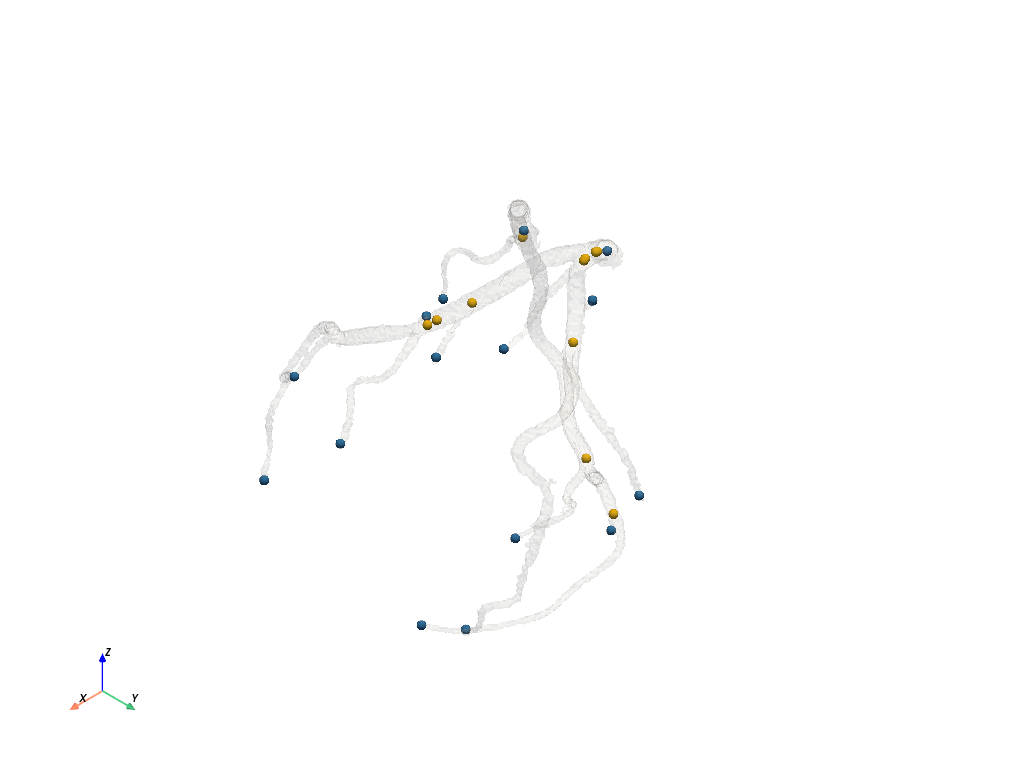

In [8]:
# ── 3D Visualization: show only key PointType classes (no Standard) ───

# Build a surface from the full (unseparated) mask for visual context
vtk_full = numpy_to_vtk_image(mask, spacing, origin)
mc_full = vmtkscripts.vmtkMarchingCubes()
mc_full.Image = vtk_full
mc_full.Level = 0.5
mc_full.Execute()
full_mesh = pv.wrap(mc_full.Surface)

cl_pts = df_centerlines[["Px", "Py", "Pz"]].values
pt = df_centerlines["PointType"].values

m_ost = pt == "Ostium"
m_end = pt == "Endpoint"
m_bif = pt == "Bifurcation"

print(f"Ostium points      : {int(m_ost.sum())}")
print(f"Endpoint points    : {int(m_end.sum())}")
print(f"Bifurcation points : {int(m_bif.sum())}")

pl = pv.Plotter()
pl.add_mesh(
    full_mesh,
    color="white",
    opacity=0.12,
    show_edges=False,
)

# Explicit layers so each class has a clear color/style.
if m_ost.any():
    pl.add_mesh(
        pv.PolyData(cl_pts[m_ost]),
        color="#e41a1c",  # red
        point_size=10,
        opacity=1.0,
        render_points_as_spheres=True,
    )

if m_end.any():
    pl.add_mesh(
        pv.PolyData(cl_pts[m_end]),
        color="#377eb8",  # blue
        point_size=10,
        opacity=1.0,
        render_points_as_spheres=True,
    )

if m_bif.any():
    pl.add_mesh(
        pv.PolyData(cl_pts[m_bif]),
        color="#ffbf00",  # amber/yellow, distinct from red/blue
        point_size=10,
        opacity=1.0,
        render_points_as_spheres=True,
    )

pl.add_axes()
pl.show()

Ostium points      : 2
Endpoint points    : 26
Bifurcation points : 11


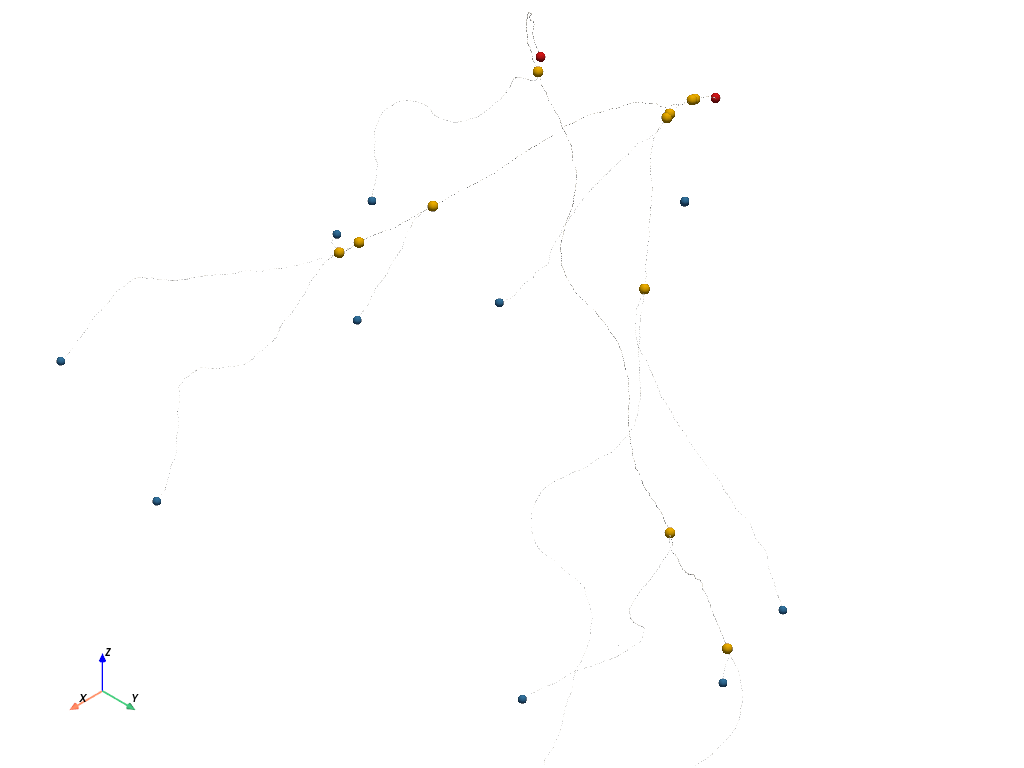

In [9]:
# ── Extra 3D view: extracted centerline + colored key point types ─────────

# Centerline point cloud
cl_pts = df_centerlines[["Px", "Py", "Pz"]].values
pt = df_centerlines["PointType"].values

m_ost = pt == "Ostium"
m_end = pt == "Endpoint"
m_bif = pt == "Bifurcation"

print(f"Ostium points      : {int(m_ost.sum())}")
print(f"Endpoint points    : {int(m_end.sum())}")
print(f"Bifurcation points : {int(m_bif.sum())}")

for _backend in ("trame", "static"):
    try:
        pv.set_jupyter_backend(_backend)
        break
    except Exception:
        continue

pl = pv.Plotter()

# Base centerline (all extracted points) as dotted cloud
pl.add_mesh(
    pv.PolyData(cl_pts),
    color="white",
    point_size=1,
    opacity=0.30,
    render_points_as_spheres=True,
)

# Highlight requested classes (slightly larger for easier inspection)
if m_ost.any():
    pl.add_mesh(
        pv.PolyData(cl_pts[m_ost]),
        color="#e41a1c",  # red
        point_size=10,
        opacity=1.0,
        render_points_as_spheres=True,
    )

if m_end.any():
    pl.add_mesh(
        pv.PolyData(cl_pts[m_end]),
        color="#377eb8",  # blue
        point_size=9,
        opacity=1.0,
        render_points_as_spheres=True,
    )

if m_bif.any():
    pl.add_mesh(
        pv.PolyData(cl_pts[m_bif]),
        color="#ffbf00",  # amber
        point_size=11,
        opacity=1.0,
        render_points_as_spheres=True,
    )

# Start with a closer camera; still fully interactive (rotate/pan/zoom)
pl.camera.zoom(2.0)
pl.add_axes()
pl.show()

In [10]:
# ── Export sample package for Block 2 (global + artery + branches) ───────


def _find_repo_results_dir() -> Path:
    """Locate `<repo>/results` from current working directory."""
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        cand = base / "results"
        if cand.is_dir():
            return cand
    return (here / "results").resolve()


results_root = _find_repo_results_dir()
sample_name = f"Normal_{SAMPLE_ID}"

# Requested structure:
# results/block1_results/samples/Normal_<id>/
#   - dataset_global.xlsx
#   - centerline_LCA.vtp
#   - centerline_RCA.vtp
#   - branches/
#       - centerlines/*.vtp
#       - dataframes/*.xlsx
sample_dir = results_root / "block1_results" / "samples" / sample_name
branches_center_dir = sample_dir / "branches" / "centerlines"
branches_df_dir = sample_dir / "branches" / "dataframes"
for d in (sample_dir, branches_center_dir, branches_df_dir):
    d.mkdir(parents=True, exist_ok=True)

# 1) Global dataset (all points from RCA + LCA)
global_xlsx = sample_dir / f"dataset_global_{sample_name}.xlsx"
df_centerlines.to_excel(global_xlsx, index=False)

# 2) Artery centerlines + artery dataframes
artery_exports = []
for artery_name in ("LCA", "RCA"):
    info = artery_outputs.get(artery_name)
    if info is None:
        continue

    centerline_path = sample_dir / f"centerline_{artery_name}.vtp"
    info["centerline_poly"].save(centerline_path)

    artery_df_xlsx = sample_dir / f"dataset_{artery_name}_{sample_name}.xlsx"
    info["df_artery"].to_excel(artery_df_xlsx, index=False)

    artery_exports.append((artery_name, centerline_path, artery_df_xlsx, len(info["df_artery"])))

    # 3) Branch centerlines + branch dataframes
    for b in info["branches"]:
        branch_id = b["branch_id"]
        branch_vtp = branches_center_dir / f"centerline_{branch_id}_{sample_name}.vtp"
        branch_xlsx = branches_df_dir / f"dataset_{branch_id}_{sample_name}.xlsx"
        b["poly"].save(branch_vtp)
        b["df"].to_excel(branch_xlsx, index=False)

n_branches = sum(len(v["branches"]) for v in artery_outputs.values())

print("Export completed.")
print(f"Sample folder : {sample_dir}")
print(f"Global XLSX   : {global_xlsx}")
for artery_name, vtp, xlsx, nrows in artery_exports:
    print(f"{artery_name} VTP     : {vtp}")
    print(f"{artery_name} XLSX    : {xlsx}  (rows={nrows:,})")
print(f"Branch VTP dir : {branches_center_dir}")
print(f"Branch XLSX dir: {branches_df_dir}")
print(f"Total branches : {n_branches}")

Export completed.
Sample folder : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\samples\Normal_1
Global XLSX   : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\samples\Normal_1\dataset_global_Normal_1.xlsx
LCA VTP     : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\samples\Normal_1\centerline_LCA.vtp
LCA XLSX    : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\samples\Normal_1\dataset_LCA_Normal_1.xlsx  (rows=3,306)
RCA VTP     : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\samples\Normal_1\centerline_RCA.vtp
RCA XLSX    : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\samples\Normal_1\dataset_RCA_Normal_1.xlsx  (rows=3,990)
Branch VTP dir : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\samples\Normal_1\branches\centerl

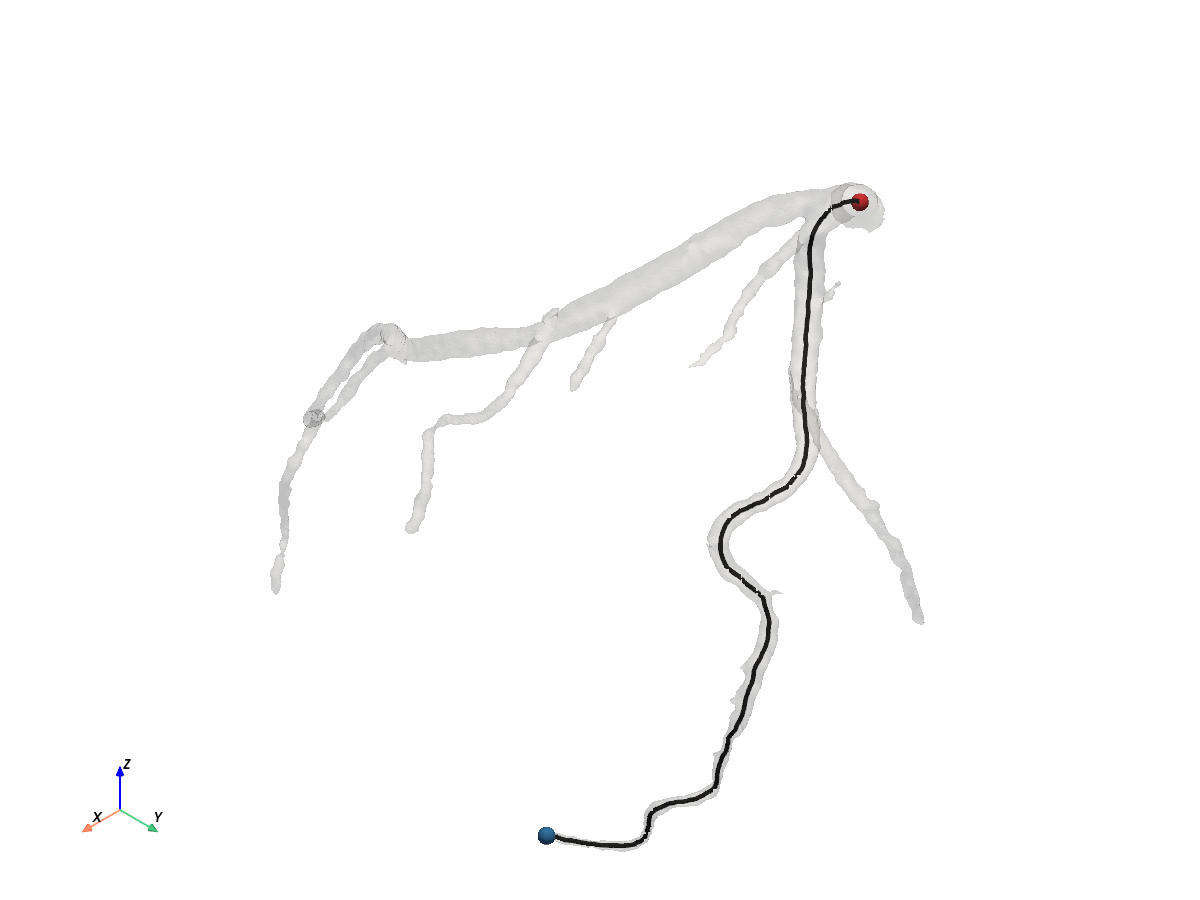

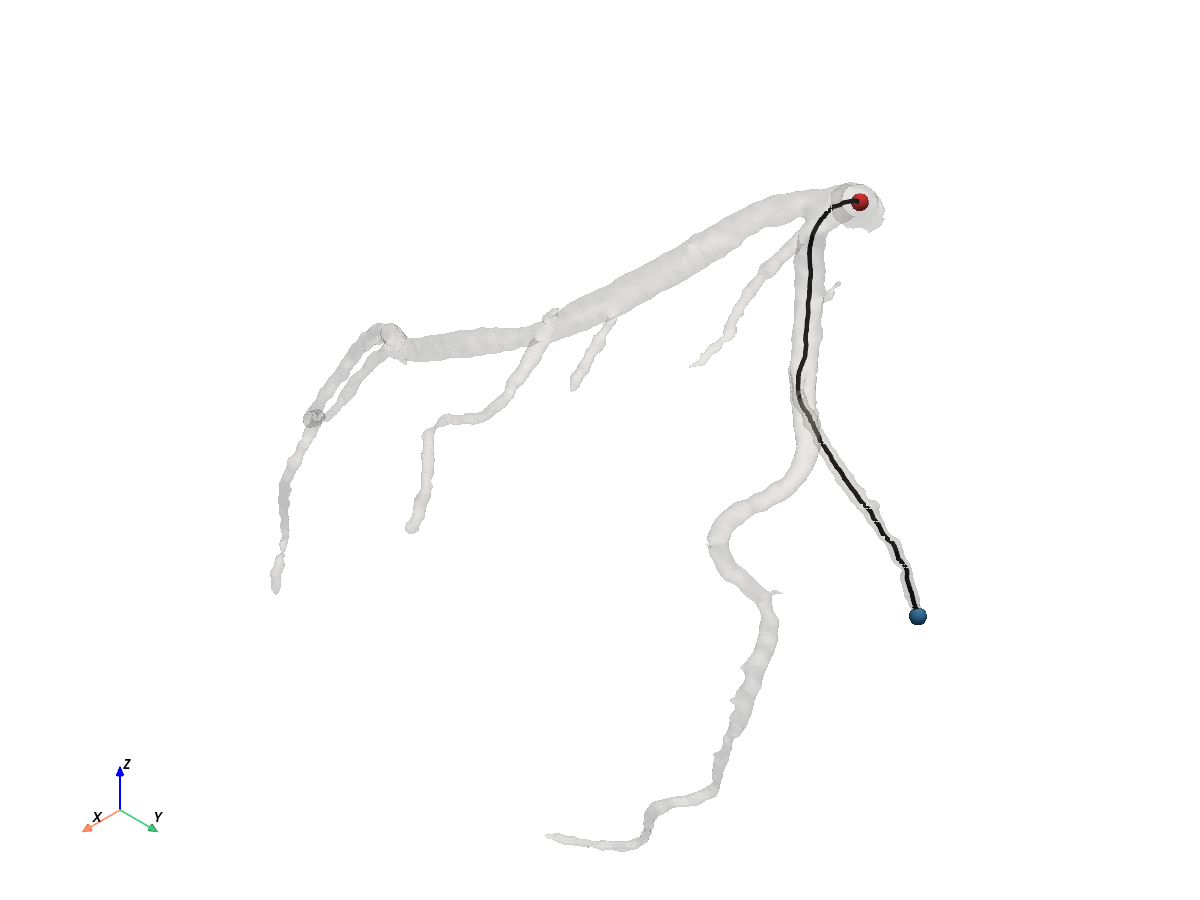

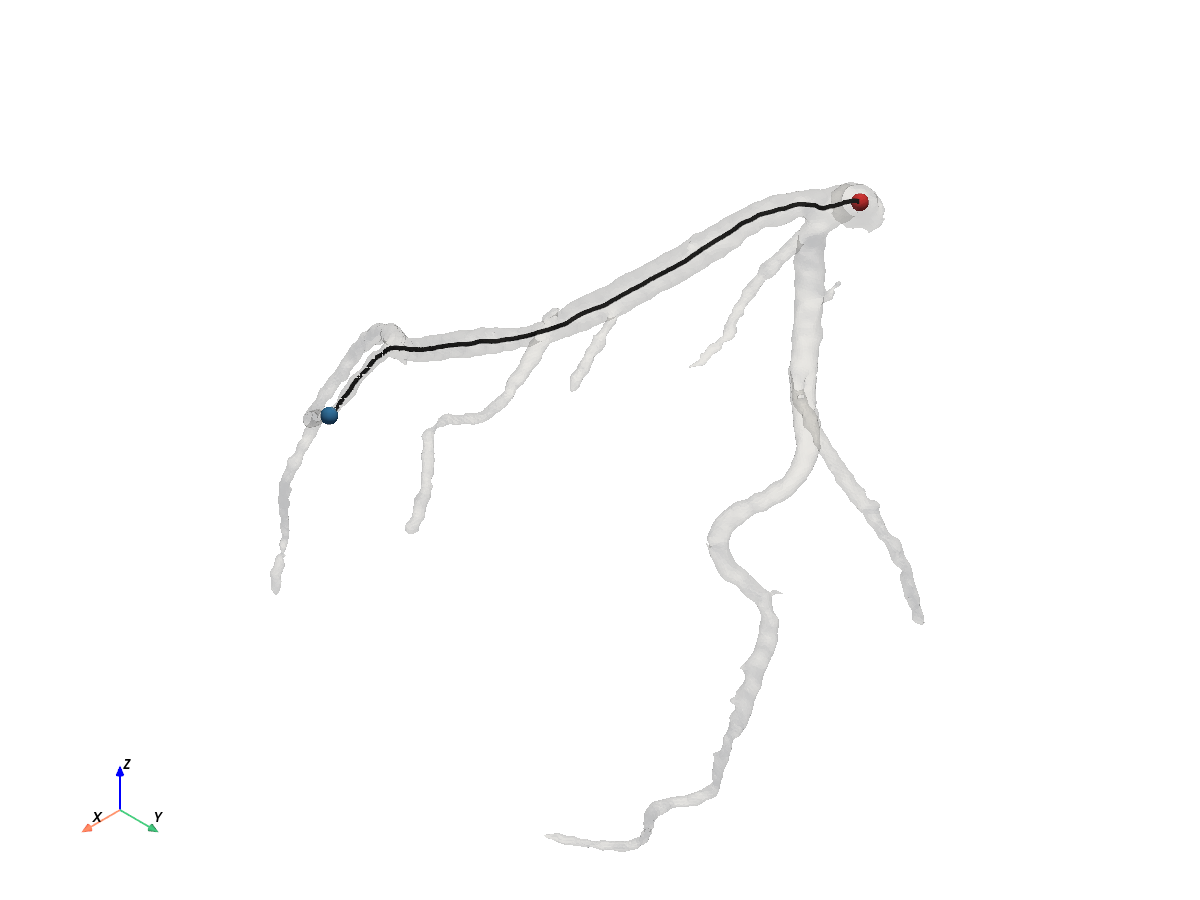

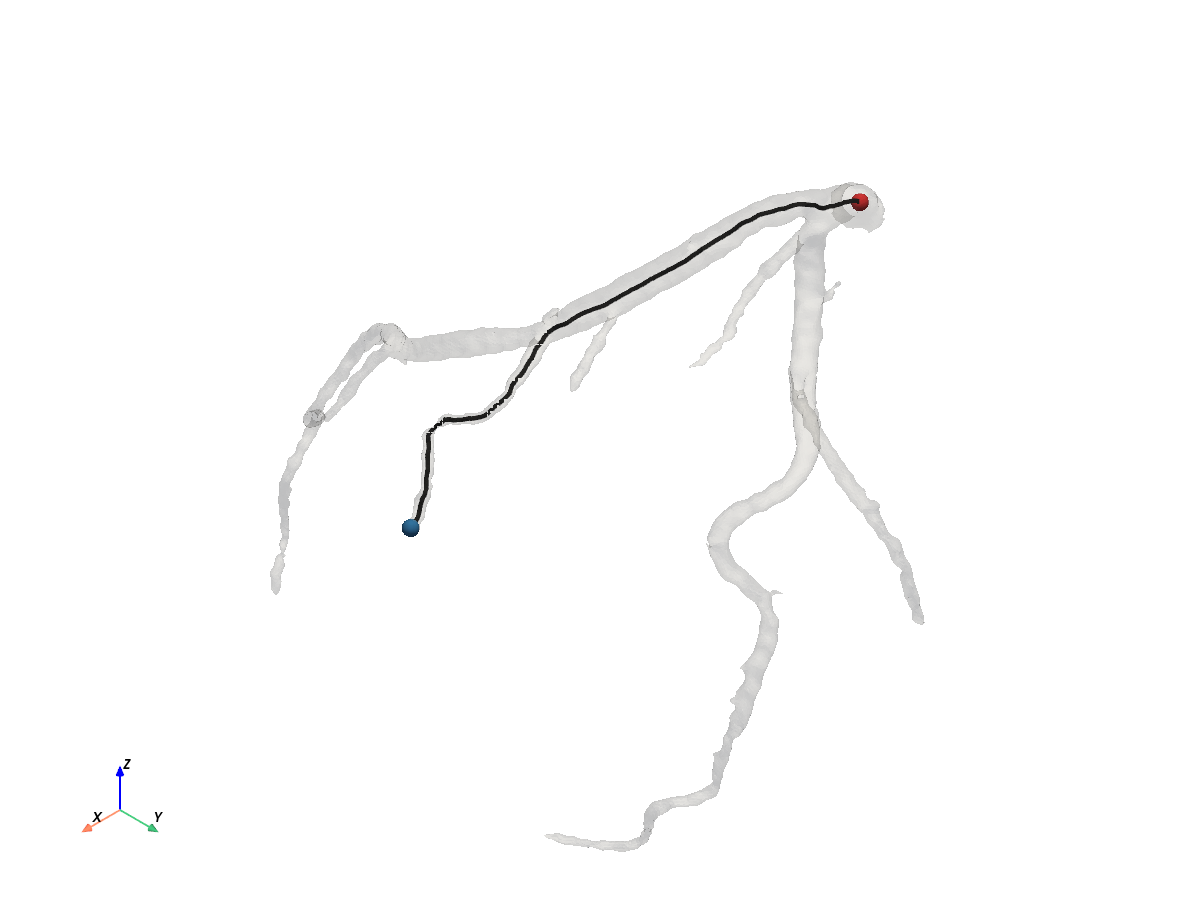

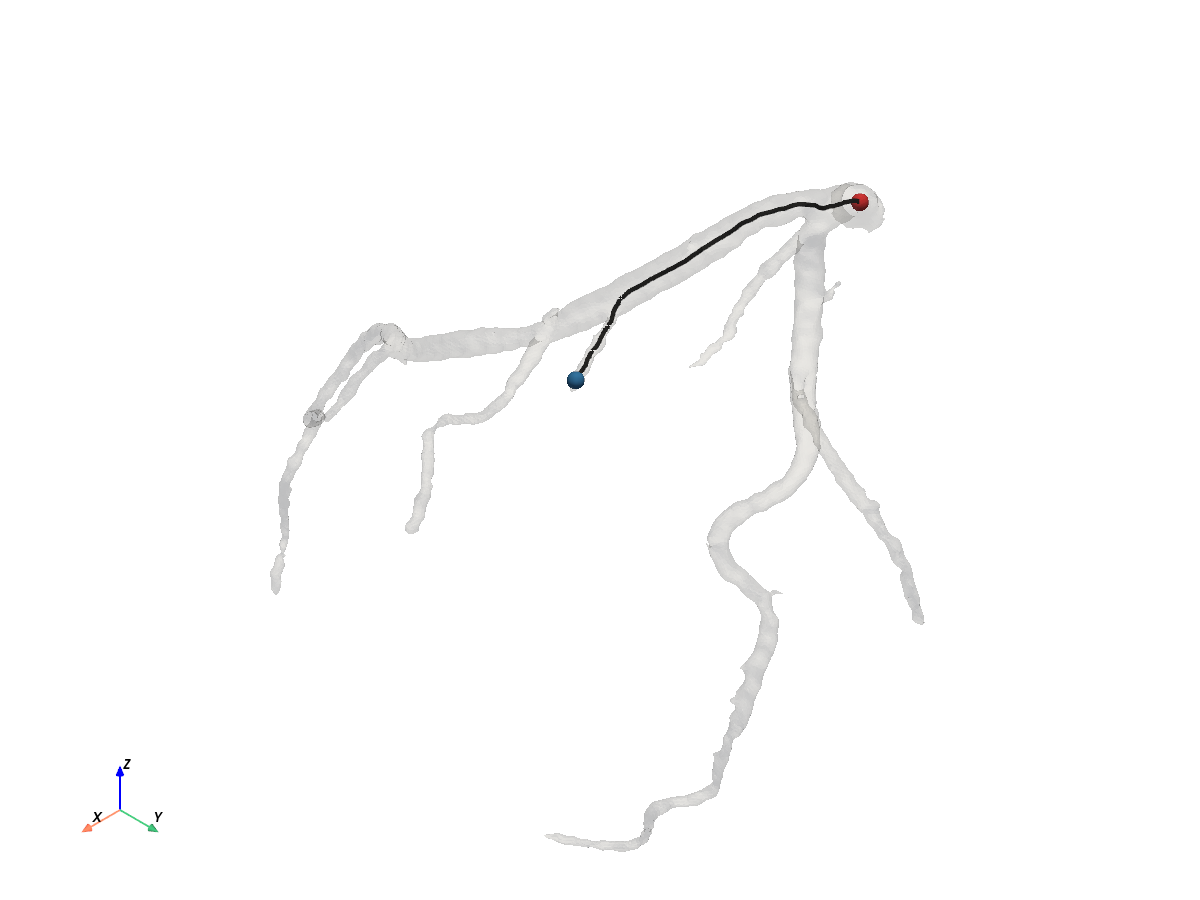

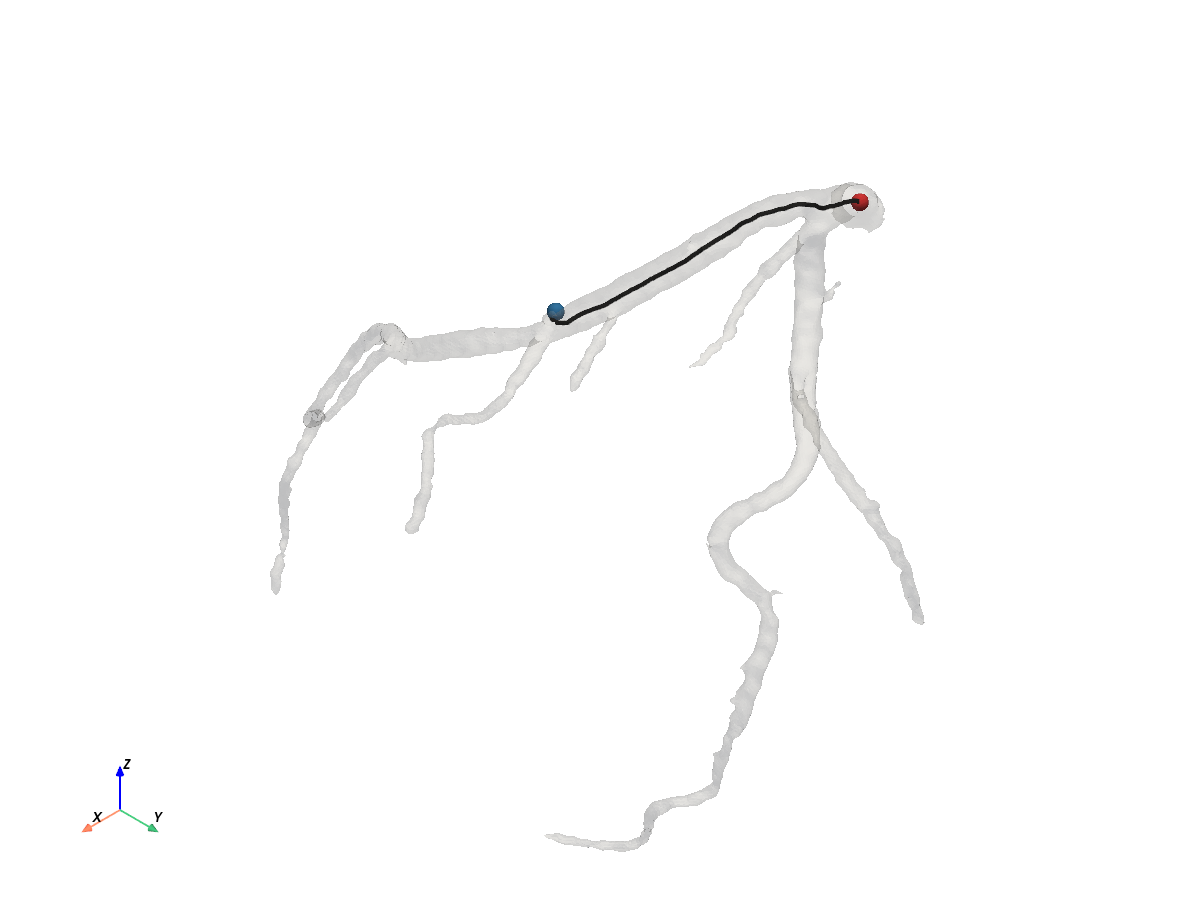

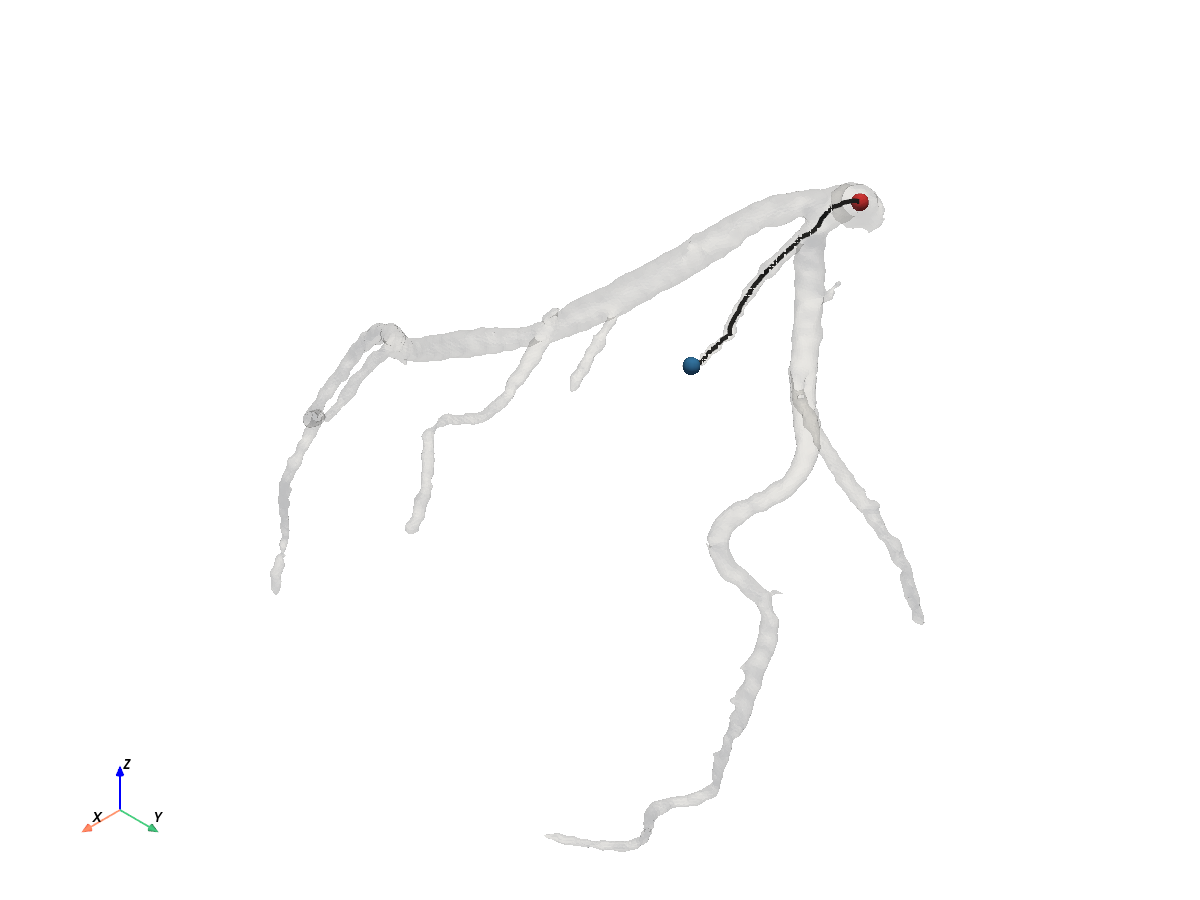

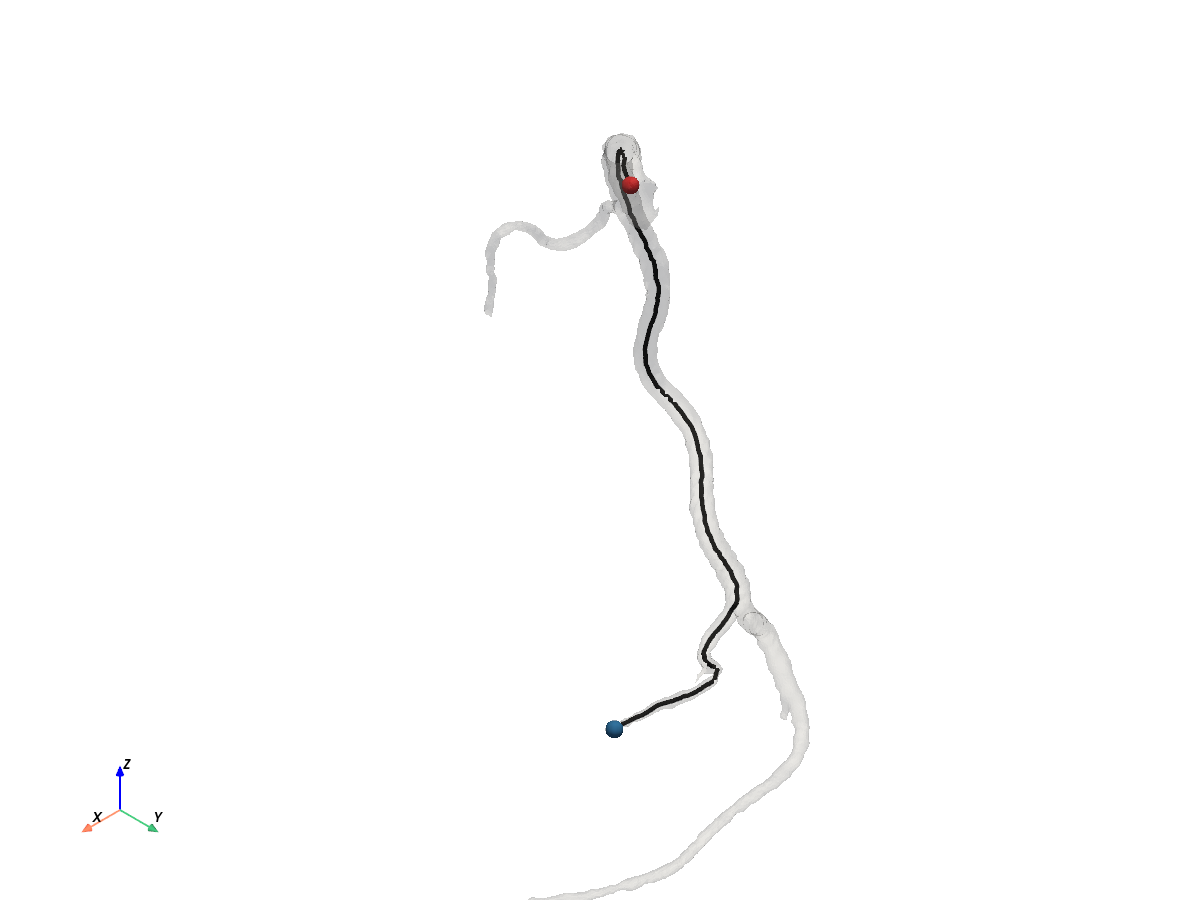

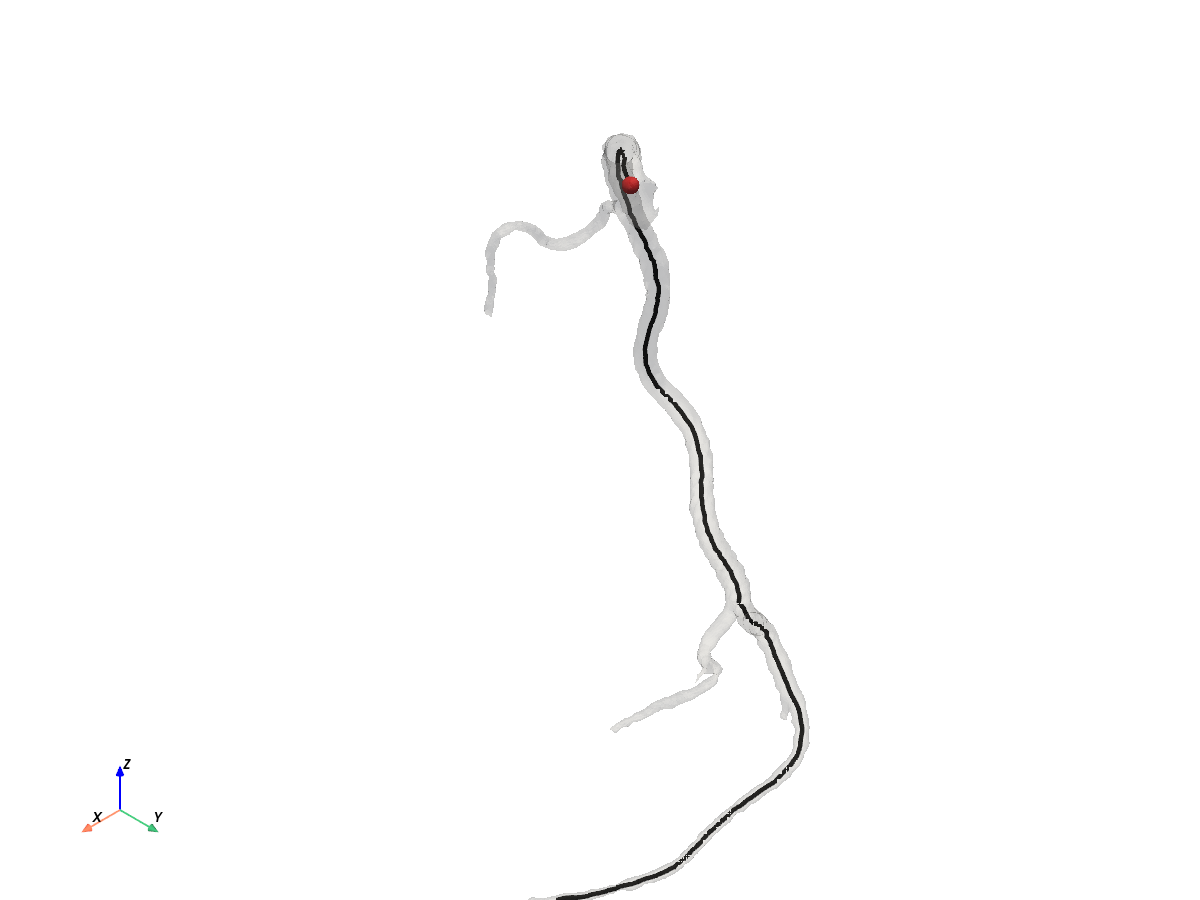

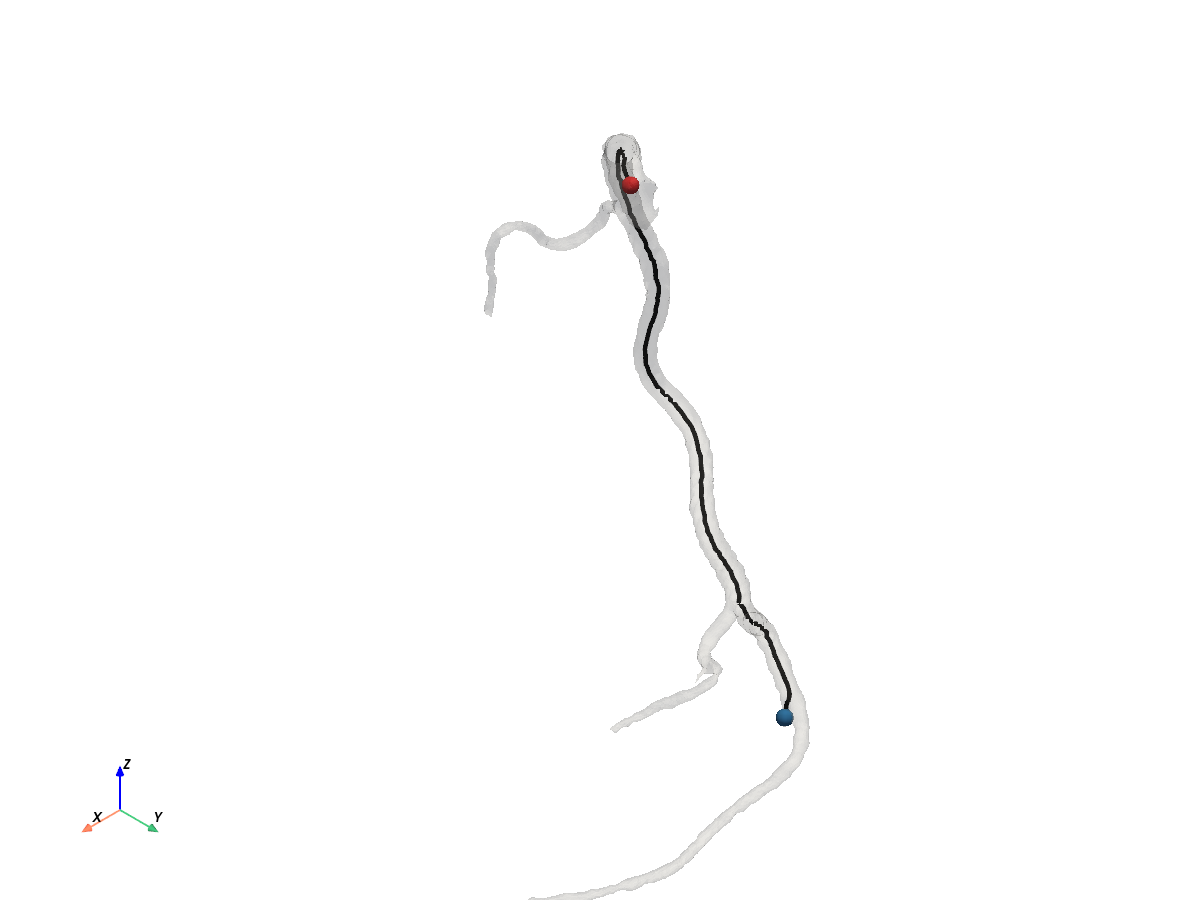

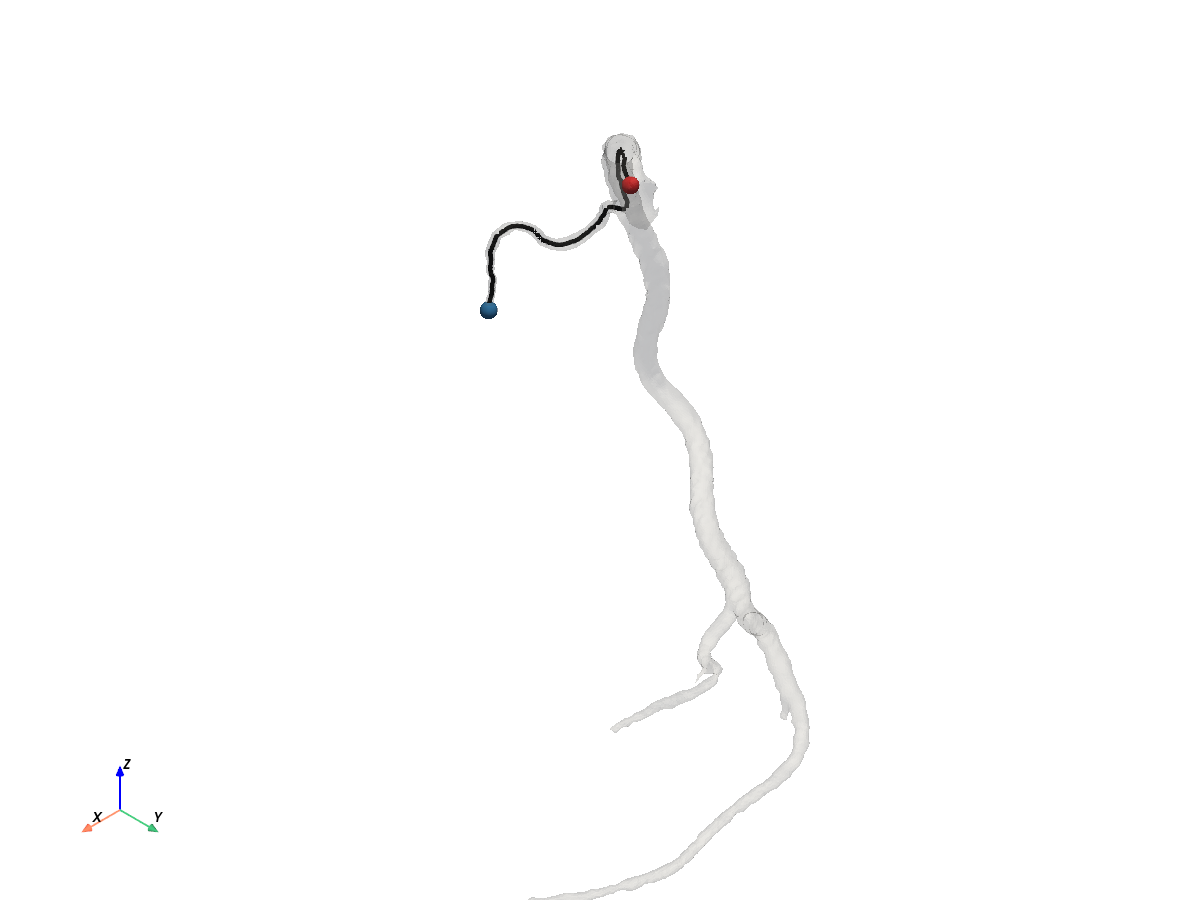

Saved 11 branch QC figures to: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\samples\Normal_1\branches\figures


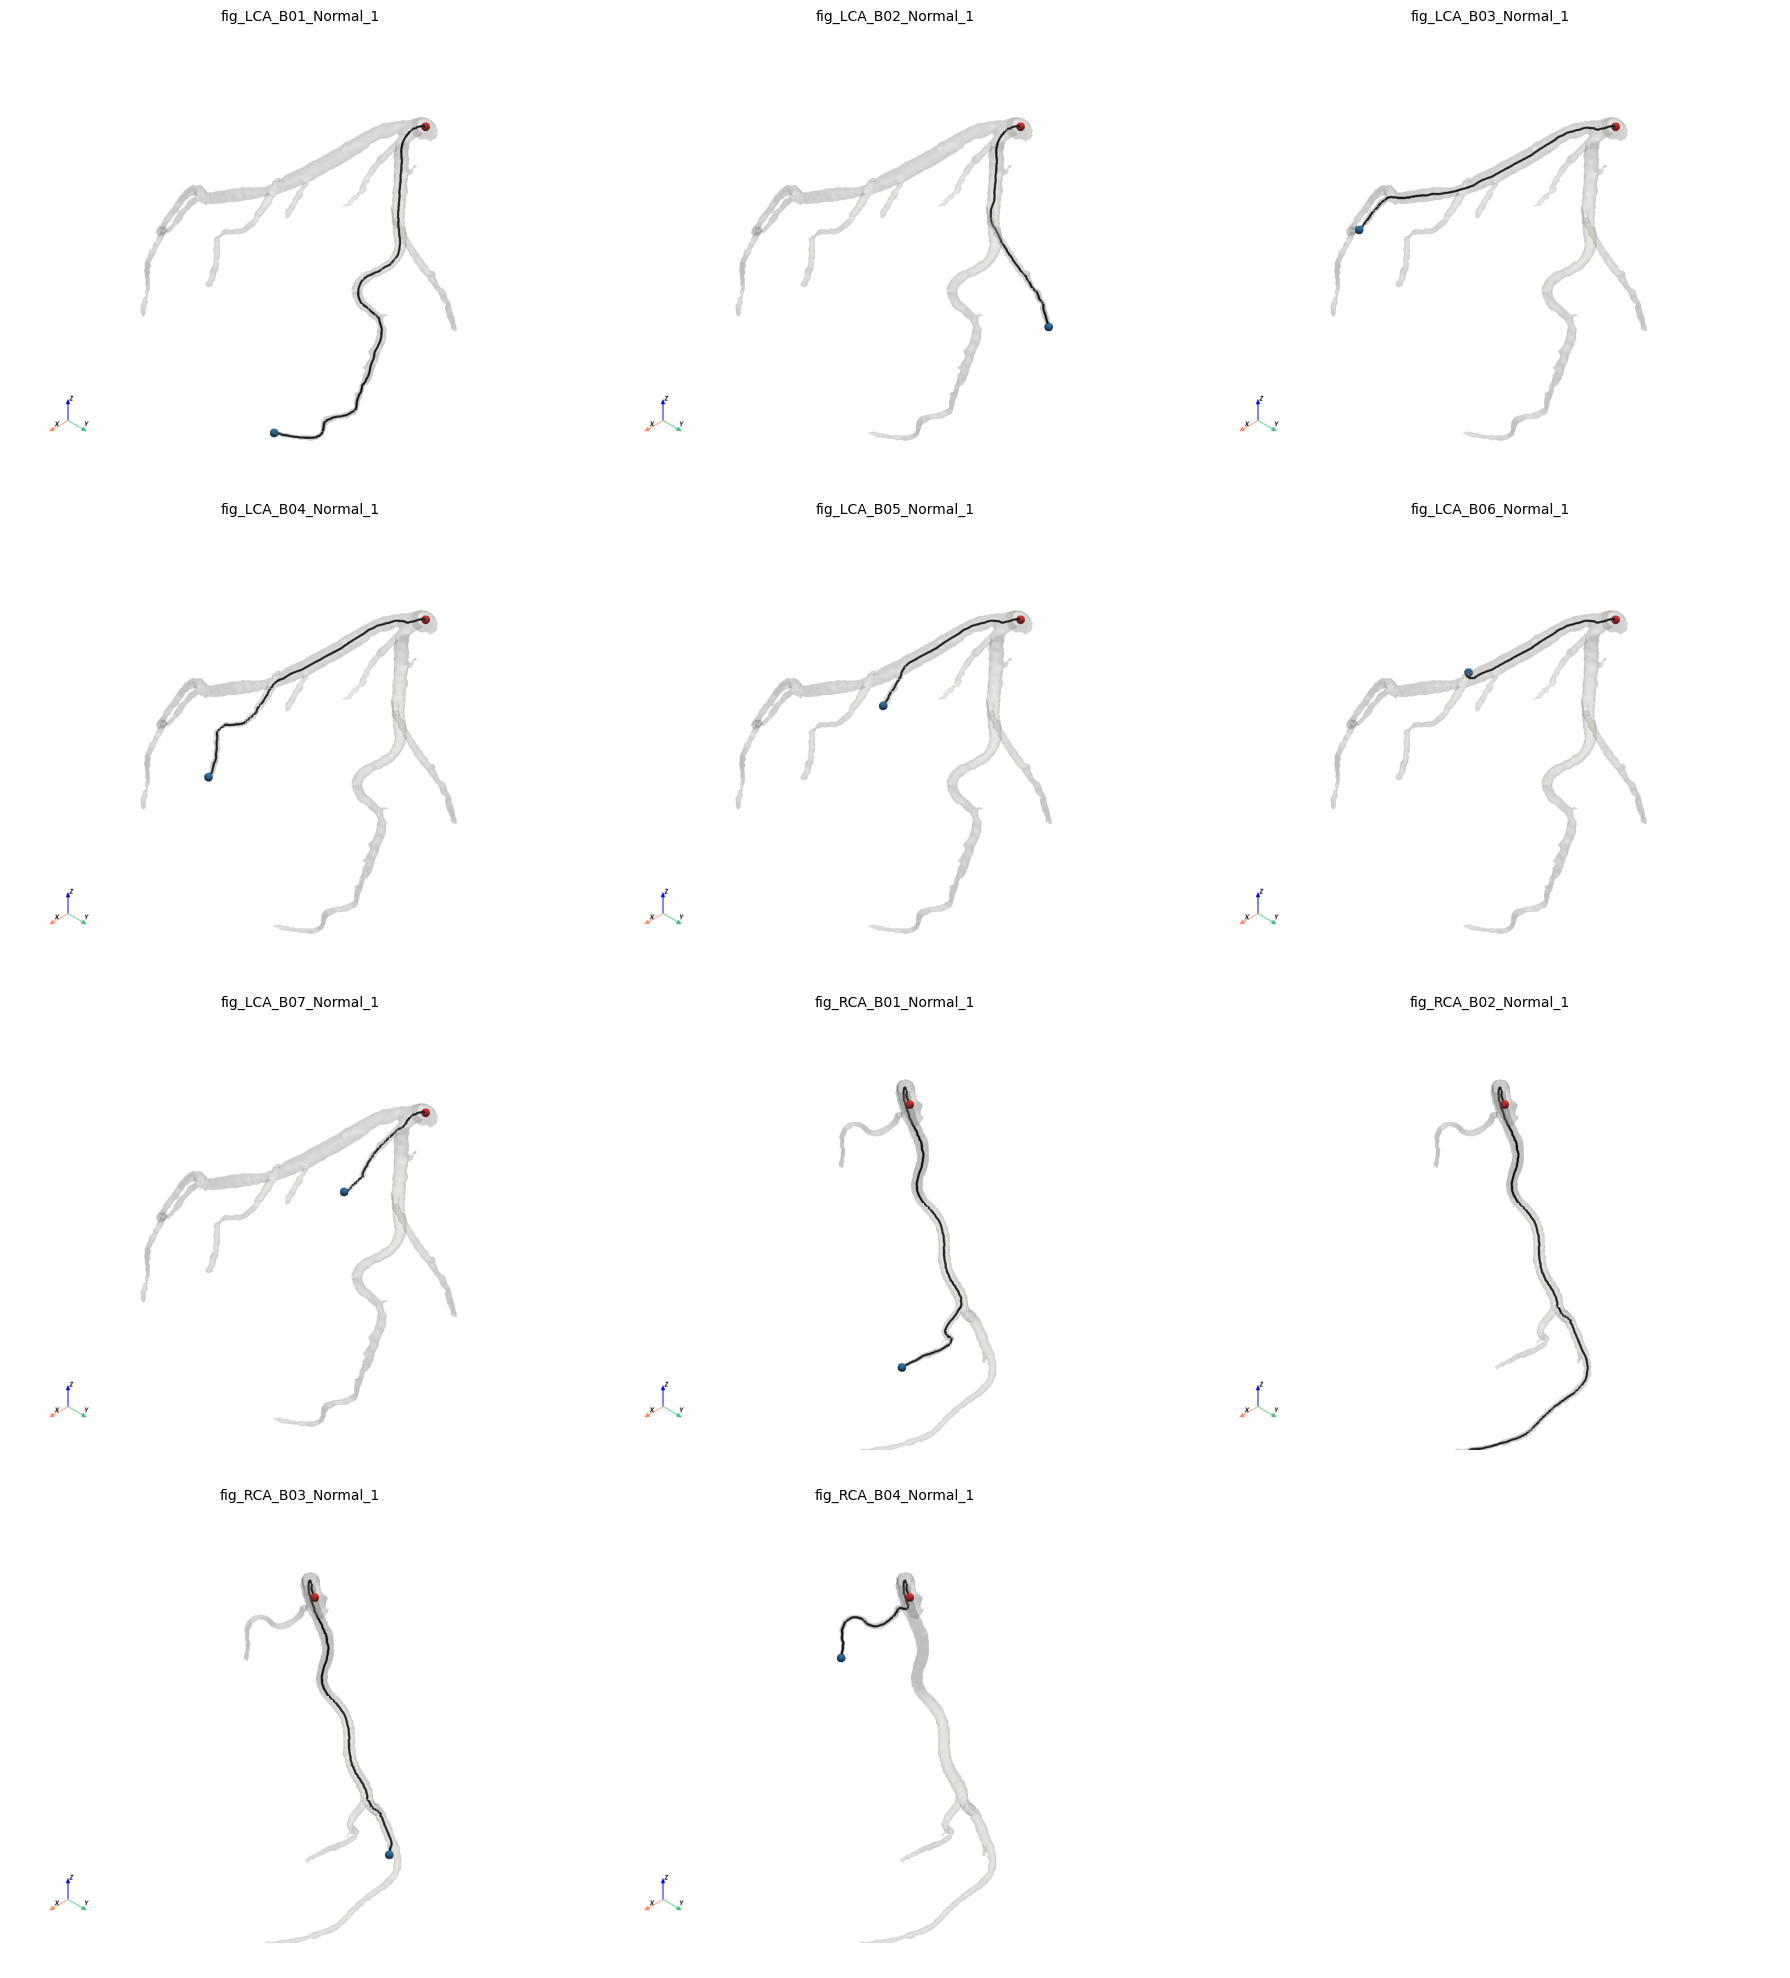

In [11]:
# ── Branch path QC figures: one figure per ostium -> branch tip path ──────
from IPython.display import display
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Ensure static rendering for notebook previews
try:
    pv.set_jupyter_backend("static")
except Exception:
    pass

# Recompute sample folder path (independent from previous cells)
try:
    _results_root = _find_repo_results_dir()
except NameError:
    def _find_repo_results_dir() -> Path:
        here = Path.cwd().resolve()
        for base in [here, *here.parents]:
            cand = base / "results"
            if cand.is_dir():
                return cand
        return (here / "results").resolve()
    _results_root = _find_repo_results_dir()

_sample_name = f"Normal_{SAMPLE_ID}"
_sample_dir = _results_root / "block1_results" / "samples" / _sample_name
fig_dir = _sample_dir / "branches" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

saved_figs = []

for artery_name in ("LCA", "RCA"):
    info = artery_outputs.get(artery_name)
    if info is None:
        continue

    # Backward-compatible fallback when artery_outputs was built in an older run
    # (without mesh_smooth key). In that case, use full_mesh if available.
    vessel_mesh = info.get("mesh_smooth", globals().get("full_mesh", None))

    for b in info["branches"]:
        branch_id = b["branch_id"]
        bpoly = b["poly"]
        bpts = np.asarray(bpoly.points)
        if len(bpts) < 2:
            continue

        ost_pt = bpts[0:1]
        tip_pt = bpts[-1:]

        png_path = fig_dir / f"fig_{branch_id}_{_sample_name}.png"

        pl = pv.Plotter(off_screen=True, window_size=(1200, 900))
        pl.set_background("white")

        # Artery context (optional if mesh is unavailable in current kernel state)
        if vessel_mesh is not None:
            pl.add_mesh(vessel_mesh, color="lightgray", opacity=0.20, show_edges=False)

        # Branch centerline path
        pl.add_mesh(bpoly, color="black", line_width=5)

        # Start (ostium) and end (branch tip) markers
        pl.add_points(
            ost_pt,
            color="#e41a1c",
            point_size=18,
            render_points_as_spheres=True,
        )
        pl.add_points(
            tip_pt,
            color="#377eb8",
            point_size=18,
            render_points_as_spheres=True,
        )

        # Show full artery context in every figure.
        pl.view_isometric()
        pl.reset_camera()
        pl.camera.zoom(1.2)  # slight zoom-out so mesh is not cut
        pl.add_axes()
        pl.show(screenshot=str(png_path), auto_close=True)
        saved_figs.append(png_path)

print(f"Saved {len(saved_figs)} branch QC figures to: {fig_dir}")

# Preview figures as a grid for easier comparison
if len(saved_figs) > 0:
    ncols = 3
    nrows = int(math.ceil(len(saved_figs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    for i, p in enumerate(saved_figs):
        r = i // ncols
        c = i % ncols
        ax = axes[r, c]
        img = mpimg.imread(str(p))
        ax.imshow(img)
        ax.set_title(p.stem, fontsize=10)
        ax.axis("off")

    # Hide any unused panels
    for j in range(len(saved_figs), nrows * ncols):
        r = j // ncols
        c = j % ncols
        axes[r, c].axis("off")

    plt.tight_layout()
    display(fig)
    plt.close(fig)